# 07. GARCH + Q_FIXED 최적 Q 민감도 분석

## 목적
GARCH vol 소스 + Q_FIXED 전략에서 Q 값에 따른 포트폴리오 성과 변화 분석

## 설계
- Vol 소스: **GARCH** 고정 (04_VolatilityPrediction.ipynb 출력)
- Q 후보: `[0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]`
- 벤치마크: CAPM, SPY (동일 기간)
- 기간: 2011-01 ~ 2025-12 (GARCH 시작에 맞춤)
- 지표: 연환산수익률, 연환산변동성, Sharpe, MDD, 누적수익률

## 파라미터 표

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 불확실성 스케일 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `Q_CANDIDATES` | [0.001~0.020] | 탐색 Q 값 목록 |
| `START_PRED` | 2011-01-01 | GARCH 가용 시작일 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '07_Q_Sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW  = 60
TAU           = 0.1
PCT_GROUP     = 0.30
START_PRED    = '2011-01-01'
Q_CANDIDATES  = [0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
vol_pivot  = panel['vol_21d'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'
vol_pred_df    = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol 로드: {vol_pred_pivot.shape}')
print(f'Q 탐색 범위: {Q_CANDIDATES}')

패널: (108135, 11)
예측 기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol 로드: (180, 610)
Q 탐색 범위: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]


# BL 구성 함수

In [2]:
def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    """BL posterior mean: μ_BL = π + τΣP^T(PτΣP^T + Ω)^{-1}(Q - Pπ)"""
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)      # Q - Pπ: BL 조정의 방향과 크기
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')

BL 함수 정의 완료


# Walk-forward: GARCH + Q 민감도

매 pred_date마다:
1. GARCH vol로 P 행렬 구성
2. Sigma, π 계산 (1회)
3. Q_CANDIDATES 각 값으로 BL → MVO → 수익률 기록
4. CAPM, SPY 벤치마크 (1회)

In [3]:
results = {f'Q={q:.3f}': [] for q in Q_CANDIDATES}
results['CAPM'] = []
results['SPY']  = []

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q 후보 {len(Q_CANDIDATES)}개: {Q_CANDIDATES}')
print(f'[GARCH vol 고정]')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        # ── 공통 데이터 준비 ─────────────────────────────────
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # ── GARCH vol 적용 ───────────────────────────────────
        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        pred_vol = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df['vol_use'] = pred_vol
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        # ── 유니버스 필터링 ──────────────────────────────────
        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)

        # ── Q 후보별 BL 실행 ─────────────────────────────────
        for q_val in Q_CANDIDATES:
            key   = f'Q={q_val:.3f}'
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[key].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

        # ── CAPM / SPY 벤치마크 ──────────────────────────────
        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        results['SPY'].append({'date': pred_date, 'ret': r_spy})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items() if v}

print(f'\n완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')

Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
Q 후보 8개: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
[GARCH vol 고정]
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료
  Q=0.001: 180개월
  Q=0.002: 180개월
  Q=0.003: 180개월
  Q=0.005: 180개월
  Q=0.007: 180개월
  Q=0.010: 180개월
  Q=0.015: 180개월
  Q=0.020: 180개월
  CAPM: 180개월
  SPY: 180개월


# 성과 분석 및 최적 Q 탐색

In [4]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

# Q 후보 → 성과 계산
ORDER = [f'Q={q:.3f}' for q in Q_CANDIDATES] + ['CAPM', 'SPY']
stats_list = [performance(ret_series[k], k) for k in ORDER if k in ret_series]
stats_df   = pd.DataFrame(stats_list).set_index('label')

# 최적 Q (Sharpe 기준)
bl_stats    = stats_df.drop(index=['CAPM', 'SPY'], errors='ignore')
optimal_key = bl_stats['sharpe'].idxmax()
optimal_q   = float(optimal_key.split('=')[1])
optimal_sharpe = bl_stats.loc[optimal_key, 'sharpe']

print('=' * 65)
print('GARCH + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)')
print('=' * 65)

disp = stats_df.copy()
disp['ann_ret'] = disp['ann_ret'].map('{:.2%}'.format)
disp['ann_vol'] = disp['ann_vol'].map('{:.2%}'.format)
disp['sharpe']  = disp['sharpe'].map('{:.3f}'.format)
disp['cum_ret'] = disp['cum_ret'].map('{:.2%}'.format)
disp['mdd']     = disp['mdd'].map('{:.2%}'.format)
disp.columns    = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']
print(disp.to_string())

print()
print(f'★ 최적 Q (Sharpe 기준): {optimal_key}  →  Sharpe {optimal_sharpe:.3f}')
print(f'  - CAPM 대비 Sharpe 우위: {optimal_sharpe - stats_df.loc["CAPM", "sharpe"]:+.3f}')
print(f'  - SPY  대비 Sharpe 우위: {optimal_sharpe - stats_df.loc["SPY",  "sharpe"]:+.3f}')

# 저장
stats_df.to_csv(OUT_DIR / 'q_sensitivity_stats.csv')
pd.DataFrame(ret_series).to_csv(DATA_DIR / 'q_sensitivity_returns.csv')
print(f'\n저장: {OUT_DIR}/q_sensitivity_stats.csv')

GARCH + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)
         연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                           
Q=0.001  13.67%  12.21%  1.001  588.51%  -17.33%
Q=0.002  13.64%  11.97%  1.018  588.23%  -17.07%
Q=0.003  13.50%  11.81%  1.019  575.70%  -16.73%
Q=0.005  13.01%  11.71%  0.986  529.50%  -16.16%
Q=0.007  12.61%  11.72%  0.951  493.21%  -16.40%
Q=0.010  12.00%  11.80%  0.893  441.28%  -17.51%
Q=0.015  11.14%  12.12%  0.798  373.21%  -22.97%
Q=0.020  10.46%  12.47%  0.721  325.32%  -26.13%
CAPM     14.21%  14.49%  0.882  612.78%  -22.17%
SPY      14.03%  14.06%  0.898     nan%  -23.93%

★ 최적 Q (Sharpe 기준): Q=0.003  →  Sharpe 1.019
  - CAPM 대비 Sharpe 우위: +0.138
  - SPY  대비 Sharpe 우위: +0.121

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/07_Q_Sensitivity/q_sensitivity_stats.csv


# 시각화

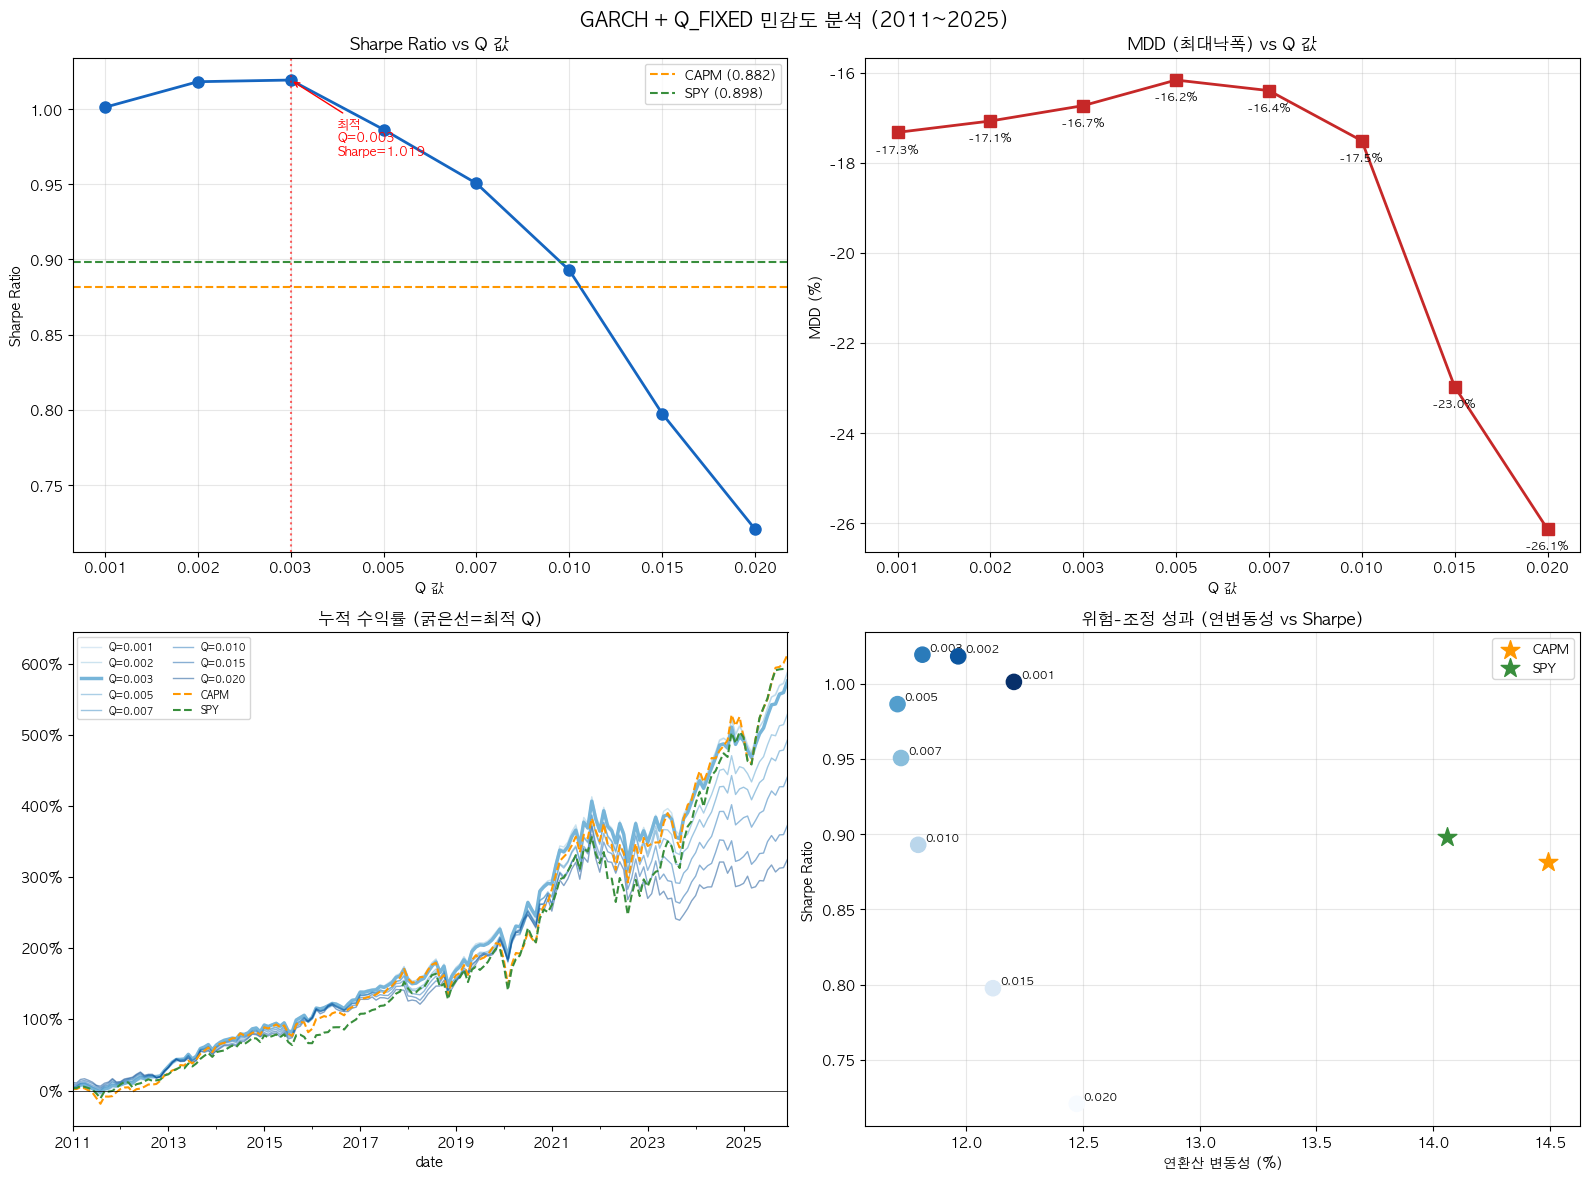


★ 최종 권장 Q 값: 0.003  (Sharpe: 1.019)


In [5]:
q_vals  = Q_CANDIDATES
sharpes = [stats_df.loc[f'Q={q:.3f}', 'sharpe'] for q in q_vals]
mdds    = [stats_df.loc[f'Q={q:.3f}', 'mdd']    for q in q_vals]
ann_rets = [stats_df.loc[f'Q={q:.3f}', 'ann_ret'] for q in q_vals]

capm_sharpe = stats_df.loc['CAPM', 'sharpe']
spy_sharpe  = stats_df.loc['SPY',  'sharpe']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GARCH + Q_FIXED 민감도 분석 (2011~2025)', fontsize=14, fontweight='bold')

# ① Sharpe vs Q
ax = axes[0, 0]
ax.plot([f'{q:.3f}' for q in q_vals], sharpes, 'o-', color='#1565C0', linewidth=2, markersize=8)
ax.axhline(capm_sharpe, color='#FF9800', linestyle='--', linewidth=1.5, label=f'CAPM ({capm_sharpe:.3f})')
ax.axhline(spy_sharpe,  color='#388E3C', linestyle='--', linewidth=1.5, label=f'SPY ({spy_sharpe:.3f})')
best_idx = sharpes.index(max(sharpes))
ax.axvline(best_idx, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax.annotate(f'최적\n{optimal_key}\nSharpe={max(sharpes):.3f}',
            xy=(best_idx, max(sharpes)), xytext=(best_idx+0.5, max(sharpes)-0.05),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
ax.set_title('Sharpe Ratio vs Q 값')
ax.set_xlabel('Q 값')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ② MDD vs Q
ax = axes[0, 1]
ax.plot([f'{q:.3f}' for q in q_vals], [m * 100 for m in mdds], 's-', color='#C62828', linewidth=2, markersize=8)
ax.set_title('MDD (최대낙폭) vs Q 값')
ax.set_xlabel('Q 값')
ax.set_ylabel('MDD (%)')
ax.grid(True, alpha=0.3)
for i, (x, y) in enumerate(zip(range(len(q_vals)), [m * 100 for m in mdds])):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, -15), ha='center', fontsize=8)

# ③ 누적 수익률 (선택 Q + 벤치마크)
ax = axes[1, 0]
palette = plt.cm.Blues(np.linspace(0.3, 0.9, len(Q_CANDIDATES)))
for j, q_val in enumerate(Q_CANDIDATES):
    key = f'Q={q_val:.3f}'
    lw  = 2.5 if key == optimal_key else 1.0
    alpha = 1.0 if key == optimal_key else 0.5
    cum = (1 + ret_series[key]).cumprod() - 1
    cum.plot(ax=ax, label=key, color=palette[j], linewidth=lw, alpha=alpha)
(1 + ret_series['CAPM']).cumprod().subtract(1).plot(ax=ax, label='CAPM', color='#FF9800', linestyle='--', linewidth=1.5)
(1 + ret_series['SPY']).cumprod().subtract(1).plot(ax=ax,  label='SPY',  color='#388E3C', linestyle='--', linewidth=1.5)
ax.set_title('누적 수익률 (굵은선=최적 Q)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=7, ncol=2)
ax.axhline(0, color='black', linewidth=0.5)

# ④ Sharpe vs 연환산수익률 (산점도)
ax = axes[1, 1]
scatter_q  = [f'Q={q:.3f}' for q in q_vals]
xs = [stats_df.loc[k, 'ann_vol'] * 100 for k in scatter_q]
ys = [stats_df.loc[k, 'sharpe']        for k in scatter_q]
sc = ax.scatter(xs, ys, c=range(len(xs)), cmap='Blues_r', s=120, zorder=5)
for j, (x, y, k) in enumerate(zip(xs, ys, scatter_q)):
    ax.annotate(k.replace('Q=', ''), (x, y), textcoords='offset points',
                xytext=(5, 3), fontsize=8)
ax.scatter([stats_df.loc['CAPM', 'ann_vol']*100], [stats_df.loc['CAPM', 'sharpe']],
           marker='*', color='#FF9800', s=200, zorder=6, label='CAPM')
ax.scatter([stats_df.loc['SPY', 'ann_vol']*100],  [stats_df.loc['SPY',  'sharpe']],
           marker='*', color='#388E3C', s=200, zorder=6, label='SPY')
ax.set_title('위험-조정 성과 (연변동성 vs Sharpe)')
ax.set_xlabel('연환산 변동성 (%)')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n★ 최종 권장 Q 값: {optimal_q:.3f}  (Sharpe: {optimal_sharpe:.3f})')

# 최적 Q → Black-Litterman 적용 방법

## BL 공식에서 Q의 역할

$$\mu_{BL} = \pi + \tau\Sigma P^T \left( P\tau\Sigma P^T + \Omega \right)^{-1} (Q - P\pi)$$

**Q가 제어하는 것**: `diff = Q - Pπ`
- `Pπ` = 현재 CAPM 균형 하에서 P 포트폴리오의 기대수익률 (음수: 저위험 long이 CAPM에서 저평가됨)
- `Q - Pπ` = BL이 μ를 π에서 얼마나 밀어낼지의 크기
- Q가 클수록 저위험 종목에 더 강한 over-weight 신호

## 실제 파이프라인 적용

```python
# 1. 최적 Q 설정
Q_OPTIMAL = optimal_q  # 위 분석에서 도출

# 2. 매월 리밸런싱 시
P     = build_P(vol_garch, mcap, pct=PCT_GROUP)   # GARCH vol → P 행렬
omega = compute_omega(P, Sigma, TAU)               # He-Litterman Ω
mu_BL = black_litterman(pi, Sigma, P, Q_OPTIMAL, omega, TAU)  # BL posterior
w_opt = optimize_portfolio(mu_BL, Sigma, lam)      # MVO 최적 비중
```

## 해석 원칙

| Q 값 | BL 조정 강도 | 포트폴리오 성격 |
|------|-------------|----------------|
| 작음 (0.001~0.003) | 약함 → CAPM에 가까움 | 분산 유지, 낮은 MDD |
| 중간 (0.005~0.007) | 중간 | 저위험 tilting 명확 |
| 큰 값 (0.015~0.020) | 강함 → 저위험 집중 | 수익률↑ but 변동성↑ |